# GBFS Feed Exploration\nInvestigate what station data is available from the Divvy real-time feeds.

In [28]:
import requests
import pandas as pd

# Discover all available feeds
gbfs = requests.get("https://gbfs.divvybikes.com/gbfs/gbfs.json").json()
feeds = {f["name"]: f["url"] for f in gbfs["data"]["en"]["feeds"]}
feeds

{'gbfs': 'https://gbfs.lyft.com/gbfs/1.1/chi/gbfs.json',
 'ebikes_at_stations': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/ebikes_at_stations.json',
 'system_information': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/system_information.json',
 'station_information': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/station_information.json',
 'station_status': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/station_status.json',
 'free_bike_status': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/free_bike_status.json',
 'system_hours': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/system_hours.json',
 'system_calendar': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/system_calendar.json',
 'system_regions': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/system_regions.json',
 'system_pricing_plans': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/system_pricing_plans.json',
 'system_alerts': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/system_alerts.json',
 'gbfs_versions': 'https://gbfs.lyft.com/gbfs/1.1/chi/en/gbfs_versions.json'}

## Station Information\nStatic metadata — name, location, capacity.

In [29]:
station_info = requests.get(feeds["station_information"]).json()
df_info = pd.DataFrame(station_info["data"]["stations"])
print(df_info.shape)
df_info.head()

(1930, 16)


,rental_uris,lon,eightd_station_services,capacity,short_name,external_id,station_type,name,electric_bike_surcharge_waiver,eightd_has_key_dispenser,lat,rental_methods,station_id,has_kiosk,region_id,address
0,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",-87.829250,[],11,CHI01891,2010820263334840794,classic,Panama Ave & Grace St,False,False,41.947660,"[KEY, CREDITCARD, TRANSITCARD]",2010820263334840794,False,NaN,NaN
1,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",-87.618617,[],31,CHI00279,a3a3e67b-a135-11e9-9cda-0a87ae2ba916,classic,New St & Illinois St,False,False,41.890847,"[KEY, CREDITCARD, TRANSITCARD]",a3a3e67b-a135-11e9-9cda-0a87ae2ba916,True,NaN,NaN
2,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",-87.641900,[],15,CHI02090,2113983884661901700,classic,Wallace St & 28th St,False,False,41.843511,"[KEY, CREDITCARD, TRANSITCARD]",2113983884661901700,True,NaN,NaN
3,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",-87.666058,[],15,CHI01143,a3b0fae6-a135-11e9-9cda-0a87ae2ba916,classic,Glenwood Ave & Touhy Ave,False,False,42.012701,"[KEY, CREDITCARD, TRANSITCARD]",a3b0fae6-a135-11e9-9cda-0a87ae2ba916,True,NaN,NaN
4,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",-87.674930,[],15,CHI00317,a3a7f0ba-a135-11e9-9cda-0a87ae2ba916,classic,Damen Ave & Madison St,False,False,41.881370,"[KEY, CREDITCARD, TRANSITCARD]",a3a7f0ba-a135-11e9-9cda-0a87ae2ba916,True,NaN,NaN


## Check Ingested Ridership Data\nRead back January 2024 from S3 dev and inspect.

In [30]:
from dotenv import load_dotenv
from divvy_demand.infra.s3_client import S3Client

load_dotenv("../.env")

s3 = S3Client(env="dev")
df = s3.read_raw(2024, 1)

print(df.shape)
print(df.dtypes)
df.head()

(144873, 13)
ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,C1D650626C8C899A,electric_bike,2024-01-12 15:30:27,2024-01-12 15:37:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.903267,-87.634737,41.889177,-87.638506,member
1,EECD38BDB25BFCB0,electric_bike,2024-01-08 15:45:46,2024-01-08 15:52:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902937,-87.634440,41.889177,-87.638506,member
2,F4A9CE78061F17F7,electric_bike,2024-01-27 12:27:19,2024-01-27 12:35:19,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902951,-87.634470,41.889177,-87.638506,member
3,0A0D9E15EE50B171,classic_bike,2024-01-29 16:26:17,2024-01-29 16:56:06,Wells St & Randolph St,TA1305000030,Larrabee St & Webster Ave,13193,41.884295,-87.633963,41.921822,-87.644140,member
4,33FFC9805E3EFF9A,classic_bike,2024-01-31 05:43:23,2024-01-31 06:09:35,Lincoln Ave & Waveland Ave,13253,Kingsbury St & Kinzie St,KA1503000043,41.948797,-87.675278,41.889177,-87.638506,member


In [31]:
df.isnull().sum()

ride_id                   0
rideable_type             0
started_at                0
ended_at                  0
start_station_name    19165
start_station_id      19165
end_station_name      20749
end_station_id        20749
start_lat                 0
start_lng                 0
end_lat                 288
end_lng                 288
member_casual             0
dtype: int64

## ETL Output Check\nRead back the processed overall data from S3 dev.

In [32]:
df_overall = s3.read_processed("station")
print(df_overall.shape)
print(df_overall.dtypes)
df_overall.head(10)

(0, 0)
Series([], dtype: object)


""


In [33]:
df_overall.isnull().sum()

Series([], dtype: float64)

## Weather Check
Read back weather data from S3 dev and inspect.

In [34]:
weather = s3.read_processed("weather")
weather["date"] = pd.to_datetime(weather["date"])
print(weather.shape)
weather.head()

(2251, 5)


,date,temp_min_c,rain_sum_mm,snowfall_sum_cm,wind_speed_max_kmh
0,2020-01-01,-6.1,0.0,0.00,35.7
1,2020-01-02,2.5,0.0,0.00,32.7
2,2020-01-03,0.2,0.0,0.00,13.4
3,2020-01-04,-2.0,0.0,1.40,21.8
4,2020-01-05,-4.8,0.0,0.07,36.0


In [35]:
weather.describe()

,date,temp_min_c,rain_sum_mm,snowfall_sum_cm,wind_speed_max_kmh
count,2251,2251.000000,2251.000000,2251.000000,2251.000000
mean,2023-01-30 00:00:00,6.605820,2.620391,0.195571,24.164727
min,2020-01-01 00:00:00,-24.900000,0.000000,0.000000,6.400000
25%,2021-07-16 12:00:00,-1.000000,0.000000,0.000000,18.350000
50%,2023-01-30 00:00:00,6.500000,0.000000,0.000000,23.200000
75%,2024-08-14 12:00:00,16.200000,1.500000,0.000000,29.000000
max,2026-02-28 00:00:00,25.900000,137.800000,11.760000,54.600000
std,NaN,10.421102,6.880898,0.902370,7.950496


In [36]:
weather.isnull().sum()

date                  0
temp_min_c            0
rain_sum_mm           0
snowfall_sum_cm       0
wind_speed_max_kmh    0
dtype: int64

## Weather Check
Read both historical and forecast-historical from S3 dev.

In [37]:
weather_hist = s3.read_processed("weather/historical")
weather_hist["date"] = pd.to_datetime(weather_hist["date"])
print("Historical shape:", weather_hist.shape)
weather_hist.head()

Historical shape: (31, 5)


,date,temp_min_c,rain_sum_mm,snowfall_sum_cm,wind_speed_max_kmh
0,2024-01-01,-2.6,0.0,0.28,30.4
1,2024-01-02,-4.6,0.0,0.00,27.1
2,2024-01-03,-1.5,0.0,0.00,17.2
3,2024-01-04,-4.6,0.0,0.00,19.8
4,2024-01-05,-5.4,0.0,0.00,17.5


In [38]:
weather_hist.describe()

,date,temp_min_c,rain_sum_mm,snowfall_sum_cm,wind_speed_max_kmh
count,31,31.00000,31.000000,31.000000,31.000000
mean,2024-01-16 00:00:00,-6.50000,2.054839,1.027419,26.051613
min,2024-01-01 00:00:00,-24.90000,0.000000,0.000000,14.700000
25%,2024-01-08 12:00:00,-11.50000,0.000000,0.000000,21.750000
50%,2024-01-16 00:00:00,-2.80000,0.000000,0.070000,25.300000
75%,2024-01-23 12:00:00,-1.00000,2.250000,0.665000,30.450000
max,2024-01-31 00:00:00,1.60000,12.900000,10.500000,45.100000
std,NaN,7.92557,3.720917,2.465444,7.324201


In [39]:
weather_hist.isnull().sum()

date                  0
temp_min_c            0
rain_sum_mm           0
snowfall_sum_cm       0
wind_speed_max_kmh    0
dtype: int64

In [40]:
weather_fcst = s3.read_processed("weather/forecast")
weather_fcst["date"] = pd.to_datetime(weather_fcst["date"])
print("Forecast shape:", weather_fcst.shape)
weather_fcst.head()

Forecast shape: (31, 5)


,date,temp_min_c,rain_sum_mm,snowfall_sum_cm,wind_speed_max_kmh
0,2024-01-01,-2.4,0.2,0.0,24.4
1,2024-01-02,-3.2,0.0,0.0,22.7
2,2024-01-03,-0.7,0.1,0.0,13.2
3,2024-01-04,-1.3,0.0,0.0,15.2
4,2024-01-05,-2.7,0.0,0.0,17.9


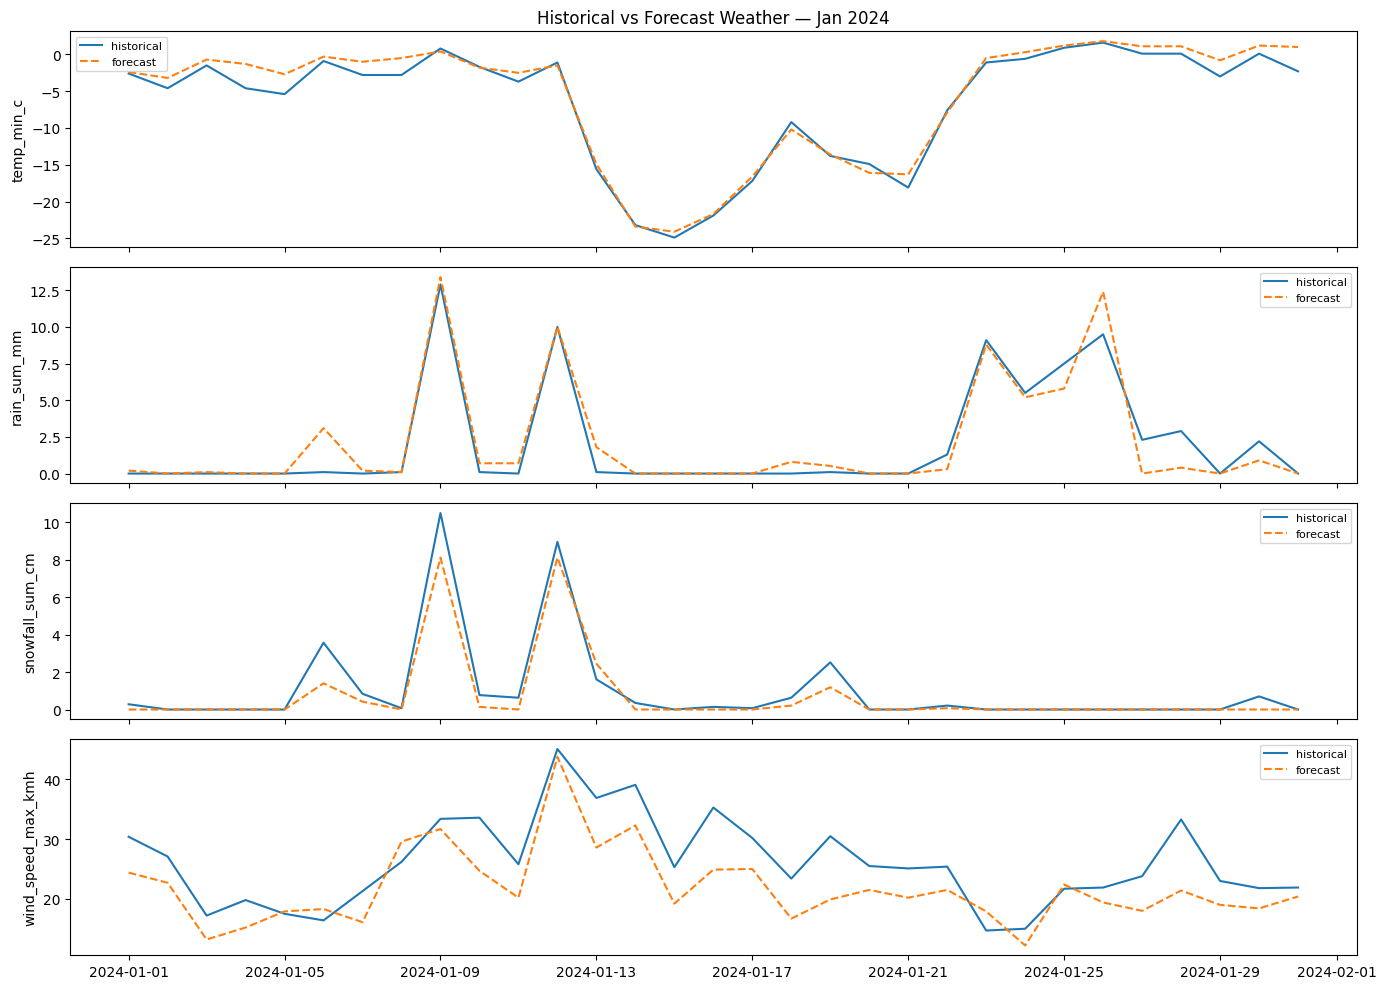

In [41]:
# Compare historical vs forecast for Jan 2024
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, ["temp_min_c", "rain_sum_mm", "snowfall_sum_cm", "wind_speed_max_kmh"]):
    ax.plot(weather_hist["date"], weather_hist[col], label="historical")
    ax.plot(weather_fcst["date"], weather_fcst[col], label="forecast", linestyle="--")
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
axes[0].set_title("Historical vs Forecast Weather — Jan 2024")
plt.tight_layout()
plt.show()

## Trip O-D Check

In [42]:
trip = s3.read_processed("trip")
trip["date"] = pd.to_datetime(trip["date"])
print(trip.shape)
trip.head()

(92685, 8)


,date,start_station_name,start_station_id,end_station_name,end_station_id,total_rides,member_rides,casual_rides
0,2024-01-01,900 W Harrison St,13028,Aberdeen St & Jackson Blvd,13157,1,1,0
1,2024-01-01,900 W Harrison St,13028,Loomis St & Lexington St,13332,1,1,0
2,2024-01-01,Aberdeen St & Jackson Blvd,13157,900 W Harrison St,13028,1,1,0
3,2024-01-01,Aberdeen St & Jackson Blvd,13157,Aberdeen St & Monroe St,13156,1,1,0
4,2024-01-01,Aberdeen St & Jackson Blvd,13157,Canal St & Harrison St,13326,1,0,1


In [43]:
trip.describe()

,date,total_rides,member_rides,casual_rides
count,92685,92685.000000,92685.000000,92685.000000
mean,2024-01-15 23:42:11.710000,1.227901,1.036791,0.191110
min,2024-01-01 00:00:00,1.000000,0.000000,0.000000
25%,2024-01-07 00:00:00,1.000000,1.000000,0.000000
50%,2024-01-16 00:00:00,1.000000,1.000000,0.000000
75%,2024-01-26 00:00:00,1.000000,1.000000,0.000000
max,2024-01-31 00:00:00,28.000000,28.000000,9.000000
std,NaN,0.797063,0.782842,0.459483


In [44]:
trip.isnull().sum()

date                  0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
total_rides           0
member_rides          0
casual_rides          0
dtype: int64

In [45]:
print("Unique routes:", trip[["start_station_name","end_station_name"]].drop_duplicates().shape[0])
print("Date range:", trip["date"].min(), "→", trip["date"].max())

Unique routes: 31425
Date range: 2024-01-01 00:00:00 → 2024-01-31 00:00:00
